# 04. Регрессия для SI

В данном ноутбуке решается задача регрессии для прогнозирования значения `SI`.

Цель работы — подготовить данные, обучить несколько моделей машинного обучения, сравнить их качество по метрикам регрессии и сделать вывод о применимости разных подходов.

In [1]:
# 1. Импорт библиотек

# Импортируем pandas для работы с табличными данными
import pandas as pd

# Импортируем numpy для численных расчётов
import numpy as np

# Импортируем matplotlib для построения графиков
import matplotlib.pyplot as plt

# Импортируем train_test_split для разделения данных на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# Импортируем StandardScaler для стандартизации признаков
from sklearn.preprocessing import StandardScaler

# Импортируем линейную регрессию
from sklearn.linear_model import LinearRegression

# Импортируем случайный лес для задачи регрессии
from sklearn.ensemble import RandomForestRegressor

# Импортируем градиентный бустинг для задачи регрессии
from sklearn.ensemble import GradientBoostingRegressor

# Импортируем метрики качества регрессии
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Импортируем GridSearchCV для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Импортируем warnings, чтобы убрать лишние предупреждения
import warnings

# Отключаем предупреждения для более аккуратного вывода
warnings.filterwarnings('ignore')

In [2]:
# 2. Загрузка обработанного датасета

# Импортируем files из Google Colab для загрузки файла с компьютера
from google.colab import files

# Загружаем обработанный CSV-файл, который был сохранён после EDA
uploaded = files.upload()

Saving processed_chemical_data.csv to processed_chemical_data.csv


In [3]:
# 3. Чтение обработанного датасета

# Считываем обработанный CSV-файл в переменную df
df = pd.read_csv('processed_chemical_data.csv')

# Проверяем, есть ли в датасете технический столбец с индексом
if 'Unnamed: 0' in df.columns:

    # Удаляем технический столбец, так как он не является химическим признаком
    df = df.drop(columns=['Unnamed: 0'])

# Выводим первые 5 строк, чтобы проверить корректность загрузки
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# 4. Подготовка признаков и целевой переменной

# Создаём список целевых переменных, которые не должны попадать в признаки
target_columns = ['IC50, mM', 'CC50, mM', 'SI']

# Формируем матрицу признаков X: удаляем из данных все целевые переменные
X = df.drop(columns=target_columns)

# Формируем целевую переменную y для задачи регрессии SI
y = df['SI']

# Проверяем размерность матрицы признаков
print('Размер X:', X.shape)

# Проверяем размерность целевой переменной
print('Размер y:', y.shape)

Размер X: (1001, 210)
Размер y: (1001,)


In [5]:
# 5. Разделение данных на обучающую и тестовую выборки

# Делим данные на обучающую и тестовую выборки в соотношении 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Выводим размер обучающей выборки
print('Размер X_train:', X_train.shape)

# Выводим размер тестовой выборки
print('Размер X_test:', X_test.shape)

Размер X_train: (800, 210)
Размер X_test: (201, 210)


In [6]:
# 6. Стандартизация признаков

# Создаём объект StandardScaler для приведения признаков к единому масштабу
scaler = StandardScaler()

# Обучаем scaler только на обучающей выборке и сразу преобразуем X_train
X_train_scaled = scaler.fit_transform(X_train)

# Преобразуем тестовую выборку с помощью scaler, обученного на X_train
X_test_scaled = scaler.transform(X_test)

# Проверяем размерность стандартизированной обучающей выборки
print('Размер X_train_scaled:', X_train_scaled.shape)

# Проверяем размерность стандартизированной тестовой выборки
print('Размер X_test_scaled:', X_test_scaled.shape)

Размер X_train_scaled: (800, 210)
Размер X_test_scaled: (201, 210)


In [7]:
# 7. Обучение базовых моделей регрессии

# Создаём словарь моделей, которые будем сравнивать между собой
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

# Создаём пустой список для сохранения результатов моделей
results = []

# Запускаем цикл по всем моделям из словаря
for model_name, model in models.items():

    # Для линейной регрессии используем стандартизированные признаки
    if model_name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    # Для древовидных моделей используем обычные признаки без стандартизации
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    # Считаем MAE — среднюю абсолютную ошибку
    mae = mean_absolute_error(y_test, y_pred)

    # Считаем RMSE — корень из среднеквадратичной ошибки
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Считаем R2 — коэффициент детерминации
    r2 = r2_score(y_test, y_pred)

    # Добавляем результаты текущей модели в общий список
    results.append([model_name, mae, rmse, r2])

# Создаём таблицу с результатами сравнения моделей
results_df = pd.DataFrame(results, columns=['Модель', 'MAE', 'RMSE', 'R2'])

# Выводим таблицу результатов
results_df

,Модель,MAE,RMSE,R2
0,Linear Regression,227.408752,1364.156638,0.073559
1,Random Forest,190.950136,1353.888381,0.087453
2,Gradient Boosting,191.301629,1357.243011,0.082926


In [8]:
# 8. Сортировка моделей по качеству

# Сортируем модели по метрике R2: чем выше R2, тем лучше модель
results_df.sort_values(by='R2', ascending=False)

,Модель,MAE,RMSE,R2
1,Random Forest,190.950136,1353.888381,0.087453
2,Gradient Boosting,191.301629,1357.243011,0.082926
0,Linear Regression,227.408752,1364.156638,0.073559


In [9]:
# 9. Подбор гиперпараметров для Random Forest

# Задаём модель Random Forest для подбора гиперпараметров
rf_model = RandomForestRegressor(random_state=42)

# Задаём сетку гиперпараметров для перебора
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Создаём объект GridSearchCV для поиска лучшей комбинации параметров
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1
)

# Обучаем GridSearchCV на обучающей выборке
grid_search.fit(X_train, y_train)

# Выводим лучшие найденные параметры
grid_search.best_params_

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}

In [10]:
# 10. Оценка лучшей модели Random Forest

# Сохраняем лучшую модель после подбора гиперпараметров
best_rf_model = grid_search.best_estimator_

# Делаем прогноз на тестовой выборке
y_pred_best_rf = best_rf_model.predict(X_test)

# Считаем MAE для лучшей модели
best_rf_mae = mean_absolute_error(y_test, y_pred_best_rf)

# Считаем RMSE для лучшей модели
best_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best_rf))

# Считаем R2 для лучшей модели
best_rf_r2 = r2_score(y_test, y_pred_best_rf)

# Выводим результаты лучшей модели
print('MAE:', best_rf_mae)
print('RMSE:', best_rf_rmse)
print('R2:', best_rf_r2)

MAE: 190.59697894960698
RMSE: 1354.5691155853908
R2: 0.08653557028343362


### Вывод по подбору гиперпараметров

Для задачи регрессии `SI` были обучены и сравнены несколько моделей: Linear Regression, Random Forest и Gradient Boosting.

Лучший результат среди базовых моделей показала модель Random Forest, однако значение R2 оказалось низким. Это говорит о том, что прогнозирование `SI` по имеющимся признакам является более сложной задачей по сравнению с прогнозированием `IC50, mM` и `CC50, mM`.

После подбора гиперпараметров качество модели существенно не улучшилось: значение R2 осталось примерно на том же уровне.

Возможная причина низкого качества заключается в том, что `SI` является производной характеристикой, связанной с `IC50` и `CC50`, а также может зависеть от более сложных нелинейных закономерностей. Для улучшения результата могут потребоваться дополнительные признаки, feature engineering, логарифмирование целевой переменной или более сложные модели.

In [11]:
# 12. Анализ важности признаков

# Обучаем итоговую модель Random Forest на обучающей выборке
final_rf_model = RandomForestRegressor(random_state=42)

# Обучаем модель на исходных признаках
final_rf_model.fit(X_train, y_train)

# Получаем важности признаков из обученной модели
feature_importances = final_rf_model.feature_importances_

# Создаём таблицу с названиями признаков и их важностью
importance_df = pd.DataFrame({
    'Признак': X.columns,
    'Важность': feature_importances
})

# Сортируем признаки по важности по убыванию
importance_df = importance_df.sort_values(by='Важность', ascending=False)

# Выводим 15 наиболее важных признаков
importance_df.head(15)

,Признак,Важность
101,VSA_EState6,0.436797
97,VSA_EState2,0.074151
12,MinPartialCharge,0.041168
27,BalabanJ,0.040015
13,MaxAbsPartialCharge,0.035010
4,qed,0.028359
104,VSA_EState9,0.013835
15,FpDensityMorgan1,0.012877
103,VSA_EState8,0.012280
105,FractionCSP3,0.011194


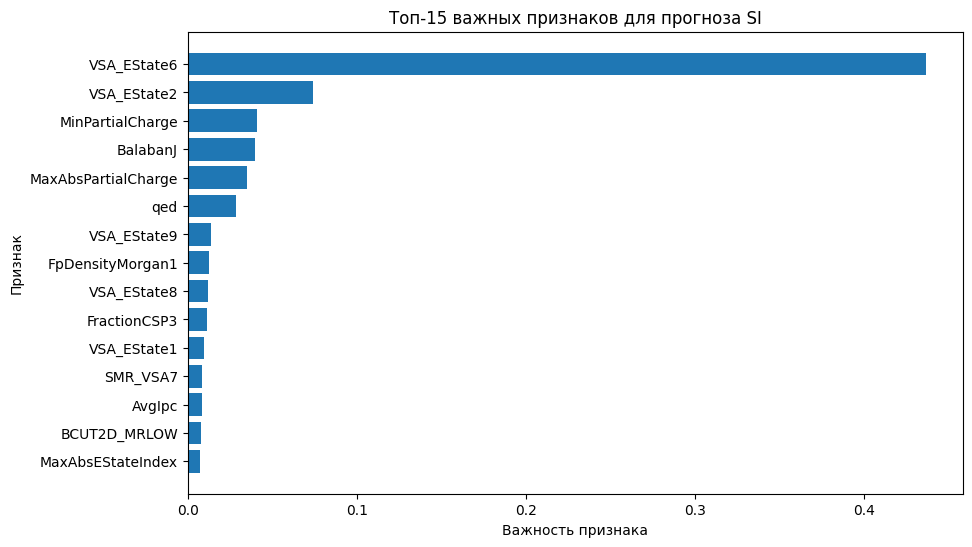

In [12]:
# 13. Визуализация важности признаков

# Берём 15 наиболее важных признаков
top_features = importance_df.head(15)

# Строим горизонтальный график важности признаков
plt.figure(figsize=(10, 6))
plt.barh(top_features['Признак'], top_features['Важность'])
plt.gca().invert_yaxis()
plt.title('Топ-15 важных признаков для прогноза SI')
plt.xlabel('Важность признака')
plt.ylabel('Признак')
plt.show()

### Вывод по важности признаков

Для итоговой модели Random Forest была рассчитана важность признаков.

Наиболее значимым признаком для прогноза `SI` оказался молекулярный дескриптор `VSA_EState6`. Также некоторую значимость показали признаки `VSA_EState2`, `MinPartialCharge`, `BalabanJ`, `MaxAbsPartialCharge` и другие.

При этом распределение важности признаков показывает, что модель сильно опирается на ограниченное число признаков. Это может быть одной из причин невысокого качества прогноза `SI`.

Важность признаков помогает интерпретировать работу модели, однако не доказывает прямую причинно-следственную связь между конкретным дескриптором и значением селективного индекса.

### Итоговый вывод по задаче регрессии SI

В данном ноутбуке была решена задача регрессии для прогнозирования значения `SI`.

Были выполнены следующие этапы:

- загружен обработанный после EDA датасет;
- удалён технический столбец `Unnamed: 0`, не являющийся химическим признаком;
- данные были разделены на обучающую и тестовую выборки;
- для линейной модели была выполнена стандартизация признаков;
- обучены и сравнены модели Linear Regression, Random Forest и Gradient Boosting;
- выполнен подбор гиперпараметров для Random Forest;
- рассчитана важность признаков для итоговой модели.

По результатам сравнения моделей лучшую метрику R2 показала модель Random Forest. Однако значение R2 оказалось низким, что говорит о сложности прогнозирования `SI` по имеющимся признакам.

В отличие от задач прогнозирования `IC50, mM` и `CC50, mM`, задача прогнозирования `SI` оказалась менее устойчивой. Возможная причина заключается в том, что `SI` является производной характеристикой и может зависеть от более сложных соотношений между свойствами соединений.

Подбор гиперпараметров Random Forest не дал существенного улучшения качества на тестовой выборке. Для дальнейшего повышения качества прогноза можно рассмотреть логарифмирование целевой переменной, расширенный feature engineering, отбор признаков и применение дополнительных моделей градиентного бустинга.